In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Set global style for academic plots
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

def plot_benchmark_comparison():
    """Generates a grouped bar chart for KGE vs HeteroGNN benchmarks."""
    models = ['TransE', 'TransR', 'RotatE', 'ComplEx', 'DistMult', 'HeteroGNN']
    dp_prauc = [0.1871, 0.2017, 0.1855, 0.2262, 0.2314, 0.5631]
    de_prauc = [0.2954, 0.2402, 0.0720, 0.2989, 0.3246, 0.8175]

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, dp_prauc, width, label='Drug-Protein PR-AUC', color='#1f77b4', edgecolor='black')
    rects2 = ax.bar(x + width/2, de_prauc, width, label='Drug-Indication PR-AUC', color='#ff7f0e', edgecolor='black')

    ax.set_ylabel('PR-AUC Score')
    ax.set_title('Benchmark Comparison: KGEs vs HeteroGNN')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.legend()

    # Add text annotations for HeteroGNN to highlight the jump
    ax.bar_label(rects1, padding=3, fmt='%.3f', fontsize=9)
    ax.bar_label(rects2, padding=3, fmt='%.3f', fontsize=9)

    plt.tight_layout()
    plt.savefig('benchmark_comparison.png', dpi=300)
    plt.close()

def plot_feature_ablation():
    """Generates a bar chart for the Feature Ablation study."""
    variants = ['Full Model\n(GAT + ESM-2)', 'Ablation 1\n(No ESM-2)', 'Ablation 2\n(No Drug Graphs)', 'Ablation 3\n(Both Ablated)', 'Morgan FP\n+ ESM-2']
    dp_prauc = [0.5631, 0.5186, 0.5785, 0.4658, 0.5286]
    
    # Colors: Highlight Ablation 2 (best) and Ablation 3 (worst)
    colors = ['#aec7e8', '#aec7e8', '#2ca02c', '#d62728', '#aec7e8']

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(variants, dp_prauc, color=colors, edgecolor='black', width=0.6)

    ax.set_ylabel('Drug-Protein PR-AUC')
    ax.set_title('Feature Ablation: Impact of Structural vs. Topological Features')
    ax.set_ylim(0.4, 0.6)

    ax.bar_label(bars, padding=3, fmt='%.4f', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig('feature_ablation.png', dpi=300)
    plt.close()

def plot_scaling_laws():
    """Generates a line plot showing Data Scaling vs Parameter Scaling."""
    # Data Scaling (Fixed Params: 3.44M)
    data_x = [25, 50, 75, 100] # Percentage of data
    data_y_dp = [0.4320, 0.5140, 0.5381, 0.5631]
    
    # Parameter Scaling (Fixed Data: 100%)
    # Params: 1.12M, 1.66M, 2.44M, 3.44M 
    # Converted to % relative to 3.44M baseline: 32.5%, 48.3%, 70.9%, 100%
    param_x = [32.5, 48.3, 70.9, 100.0]
    param_y_dp = [0.4480, 0.5216, 0.5650, 0.5631]

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(data_x, data_y_dp, marker='o', markersize=8, linewidth=2.5, color='#1f77b4', label='Data Scaling (Fixed at 3.44M Params)')
    ax.plot(param_x, param_y_dp, marker='s', markersize=8, linewidth=2.5, color='#d62728', linestyle='--', label='Param Scaling (Fixed at 100% Data)')

    ax.set_xlabel('Resource Scaled (%)', fontweight='bold')
    ax.set_ylabel('Drug-Protein PR-AUC', fontweight='bold')
    ax.set_title('Scaling Laws: Data Volume vs. Model Complexity')
    ax.set_ylim(0.40, 0.60)
    
    # Highlight the crossover insight
    ax.axvline(x=48.3, color='gray', linestyle=':', alpha=0.7)
    ax.annotate('1.66M Params (48%)\nOutperforms 50% Data', 
                xy=(48.3, 0.5216), xytext=(55, 0.47),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig('scaling_laws.png', dpi=300)
    plt.close()

if __name__ == "__main__":
    plot_benchmark_comparison()
    plot_feature_ablation()
    plot_scaling_laws()
    print("Plots generated successfully: benchmark_comparison.png, feature_ablation.png, scaling_laws.png")

Plots generated successfully: benchmark_comparison.png, feature_ablation.png, scaling_laws.png


Plot generated successfully: computational_efficiency.png


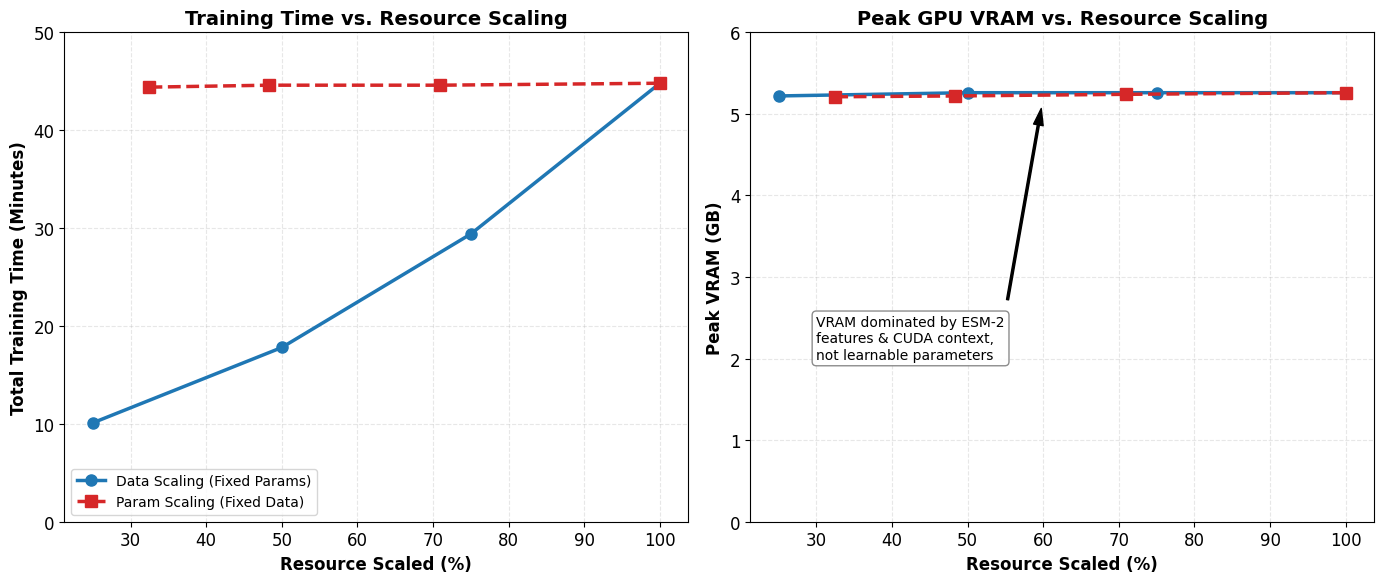

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Set global style
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

def plot_computational_efficiency():
    """Generates a side-by-side comparison of Training Time and VRAM usage."""
    
    # Data Scaling Points (Fixed Params: 3.44M)
    data_x = [25, 50, 75, 100]
    data_time = [10.1, 17.8, 29.4, 44.8]  # Minutes
    data_vram = [5.22, 5.26, 5.26, 5.26]  # Converted roughly to GB
    
    # Param Scaling Points (Fixed Data: 100%)
    param_x = [32.5, 48.3, 70.9, 100] # Param percentages
    param_time = [44.4, 44.6, 44.6, 44.8] # Minutes
    param_vram = [5.21, 5.22, 5.24, 5.26] # GB

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # --- Subplot 1: Training Time ---
    ax1.plot(data_x, data_time, marker='o', markersize=8, linewidth=2.5, color='#1f77b4', label='Data Scaling (Fixed Params)')
    ax1.plot(param_x, param_time, marker='s', markersize=8, linewidth=2.5, color='#d62728', linestyle='--', label='Param Scaling (Fixed Data)')
    ax1.set_title('Training Time vs. Resource Scaling', fontweight='bold')
    ax1.set_xlabel('Resource Scaled (%)', fontweight='bold')
    ax1.set_ylabel('Total Training Time (Minutes)', fontweight='bold')
    ax1.legend()
    ax1.set_ylim(0, 50)

    # --- Subplot 2: Peak VRAM ---
    ax2.plot(data_x, data_vram, marker='o', markersize=8, linewidth=2.5, color='#1f77b4', label='Data Scaling')
    ax2.plot(param_x, param_vram, marker='s', markersize=8, linewidth=2.5, color='#d62728', linestyle='--', label='Param Scaling')
    ax2.set_title('Peak GPU VRAM vs. Resource Scaling', fontweight='bold')
    ax2.set_xlabel('Resource Scaled (%)', fontweight='bold')
    ax2.set_ylabel('Peak VRAM (GB)', fontweight='bold')
    ax2.set_ylim(0, 6)
    
    # Annotate VRAM to explain the flatline
    ax2.annotate('VRAM dominated by ESM-2\nfeatures & CUDA context,\nnot learnable parameters', 
                 xy=(60, 5.2), xytext=(30, 2),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
                 fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

    plt.tight_layout()
    plt.savefig('computational_efficiency.png', dpi=300)
    print("Plot generated successfully: computational_efficiency.png")

if __name__ == "__main__":
    plot_computational_efficiency()

In [3]:
import torch

def measure_gpu_tflops(size=8192, iterations=100):
    if not torch.cuda.is_available():
        print("CUDA is not available. Cannot measure GPU FLOPS.")
        return

    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
    
    # Create large matrices (FP32 - Single Precision)
    A = torch.randn(size, size, dtype=torch.float32, device='cuda')
    B = torch.randn(size, size, dtype=torch.float32, device='cuda')

    # Warm-up to initialize CUDA context and avoid cold-start overhead
    print("Warming up...")
    for _ in range(10):
        _ = torch.matmul(A, B)
    torch.cuda.synchronize()

    # Timing events
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    print(f"Running benchmark ({iterations} iterations of {size}x{size} matmul)...")
    start_event.record()
    
    for _ in range(iterations):
        _ = torch.matmul(A, B)
        
    end_event.record()
    torch.cuda.synchronize()

    # Calculate time and FLOPS
    elapsed_time_ms = start_event.elapsed_time(end_event)
    elapsed_time_s = elapsed_time_ms / 1000.0

    # Operations per matrix multiplication: 2 * M * N * K
    # For square matrices of size N: 2 * N^3
    ops_per_matmul = 2 * (size ** 3)
    total_ops = ops_per_matmul * iterations

    tflops = (total_ops / elapsed_time_s) / (10**12)

    print(f"Elapsed Time: {elapsed_time_s:.4f} seconds")
    print(f"Achieved Performance: {tflops:.2f} TFLOPS (Single Precision / FP32)")

if __name__ == "__main__":
    measure_gpu_tflops()

GPU detected: NVIDIA GeForce RTX 3090
Warming up...
Running benchmark (100 iterations of 8192x8192 matmul)...
Elapsed Time: 4.6440 seconds
Achieved Performance: 23.68 TFLOPS (Single Precision / FP32)
